# 🌱 Irrigation Need Prediction

**Goal:** Predict whether a field requires **Low**, **Medium**, or **High** irrigation, using soil, weather, crop, and regional features.

**Dataset:** 630 k training rows · 270 k test rows · 20 input features  
**Target:** `Irrigation_Need` (3-class, imbalanced: ~59 % Low, ~38 % Medium, ~3 % High)

**Approach outline:**
1. Exploratory data analysis (EDA)
2. Feature engineering
3. LightGBM with stratified 5-fold cross-validation
4. Calibration & threshold search for the minority class
5. Generate `submission.csv`

## 1 · Imports & Configuration

In [4]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (accuracy_score, classification_report,
                              confusion_matrix, log_loss, f1_score)
import lightgbm as lgb

SEED = 42
N_FOLDS = 5
TARGET = "Irrigation_Need"
LABEL_ORDER = ["Low", "Medium", "High"]   # ordinal: 0, 1, 2

pd.set_option("display.max_columns", 40)
sns.set_theme(style="whitegrid", palette="muted")
print("Libraries loaded ✓")

Libraries loaded ✓


## 2 · Load Data

In [5]:
train_raw = pd.read_csv("train.csv", index_col="id")
test_raw  = pd.read_csv("test.csv",  index_col="id")

print(f"Train : {train_raw.shape}  |  Test : {test_raw.shape}")
train_raw.head(3)

Train : (630000, 20)  |  Test : (270000, 19)


,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region,Irrigation_Need
id,,,,,,,,,,,,,,,,,,,,
0,Loamy,4.92,32.58,1.01,3.05,15.01,50.61,725.99,5.90,16.79,Sugarcane,Sowing,Zaid,Drip,Rainwater,0.82,No,112.16,East,Low
1,Clay,7.08,56.61,0.44,2.00,22.92,67.86,985.66,6.98,3.39,Wheat,Vegetative,Kharif,Rainfed,River,5.27,Yes,47.16,South,Low
2,Clay,5.69,27.71,0.81,2.83,26.97,92.22,2201.70,6.05,3.85,Rice,Vegetative,Kharif,Sprinkler,Reservoir,8.24,Yes,110.38,North,Low


## 3 · Exploratory Data Analysis

### 3.1 Missing values & dtypes

In [6]:
missing = train_raw.isnull().sum()
print("Missing values (train):")
print(missing[missing > 0] if missing.any() else "  None 🎉")
print()
train_raw.describe().round(2)

Missing values (train):
  None 🎉



,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Field_Area_hectare,Previous_Irrigation_mm
count,630000.00,630000.00,630000.00,630000.00,630000.00,630000.00,630000.00,630000.00,630000.00,630000.00,630000.00
mean,6.48,37.30,0.92,1.74,27.00,61.56,1462.21,7.51,10.38,7.52,62.32
std,0.92,16.38,0.37,0.95,8.62,19.71,612.99,2.00,5.69,4.22,34.25
min,4.80,8.00,0.30,0.10,12.00,25.00,0.38,4.00,0.50,0.30,0.02
25%,5.69,23.34,0.61,0.93,19.52,45.39,954.57,5.76,5.28,3.88,33.14
50%,6.44,37.75,0.91,1.74,26.96,61.65,1467.16,7.58,10.48,7.38,61.15
75%,7.27,51.27,1.22,2.58,34.54,79.12,2054.28,9.25,15.43,11.14,92.69
max,8.20,64.99,1.60,3.50,42.00,94.99,2499.69,11.00,20.00,15.00,119.99


### 3.2 Target distribution

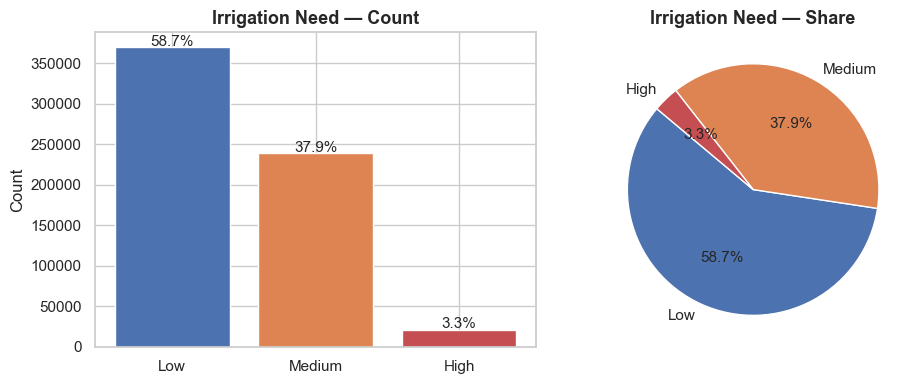

Irrigation_Need
Low       369917
Medium    239074
High       21009


In [7]:
target_counts = train_raw[TARGET].value_counts().reindex(LABEL_ORDER)
target_pct    = target_counts / len(train_raw) * 100

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Bar chart
colors = ["#4C72B0", "#DD8452", "#C44E52"]
axes[0].bar(LABEL_ORDER, target_counts.values, color=colors, edgecolor="white")
axes[0].set_title("Irrigation Need — Count", fontsize=13, fontweight="bold")
axes[0].set_ylabel("Count")
for i, (cnt, pct) in enumerate(zip(target_counts, target_pct)):
    axes[0].text(i, cnt + 2000, f"{pct:.1f}%", ha="center", fontsize=11)

# Pie chart
axes[1].pie(target_counts, labels=LABEL_ORDER, colors=colors,
            autopct="%1.1f%%", startangle=140, textprops={"fontsize": 11})
axes[1].set_title("Irrigation Need — Share", fontsize=13, fontweight="bold")

plt.tight_layout()
plt.savefig("target_distribution.png", dpi=120, bbox_inches="tight")
plt.show()
print(target_counts.to_string())

### 3.3 Numeric feature distributions by target

<div style='padding-left: 1em; font-size: 0.8em; background-color: #f0f0f8; margin-bottom: 0em;'>⚠️ The object axes (type ndarray[object, shape=(2,)]) cannot be checkpointed</div>

<div style='padding-left: 1em; font-size: 0.8em; background-color: #f0f0f8; margin-bottom: 0em;'>⚠️ The object fig (type Figure) cannot be checkpointed</div>

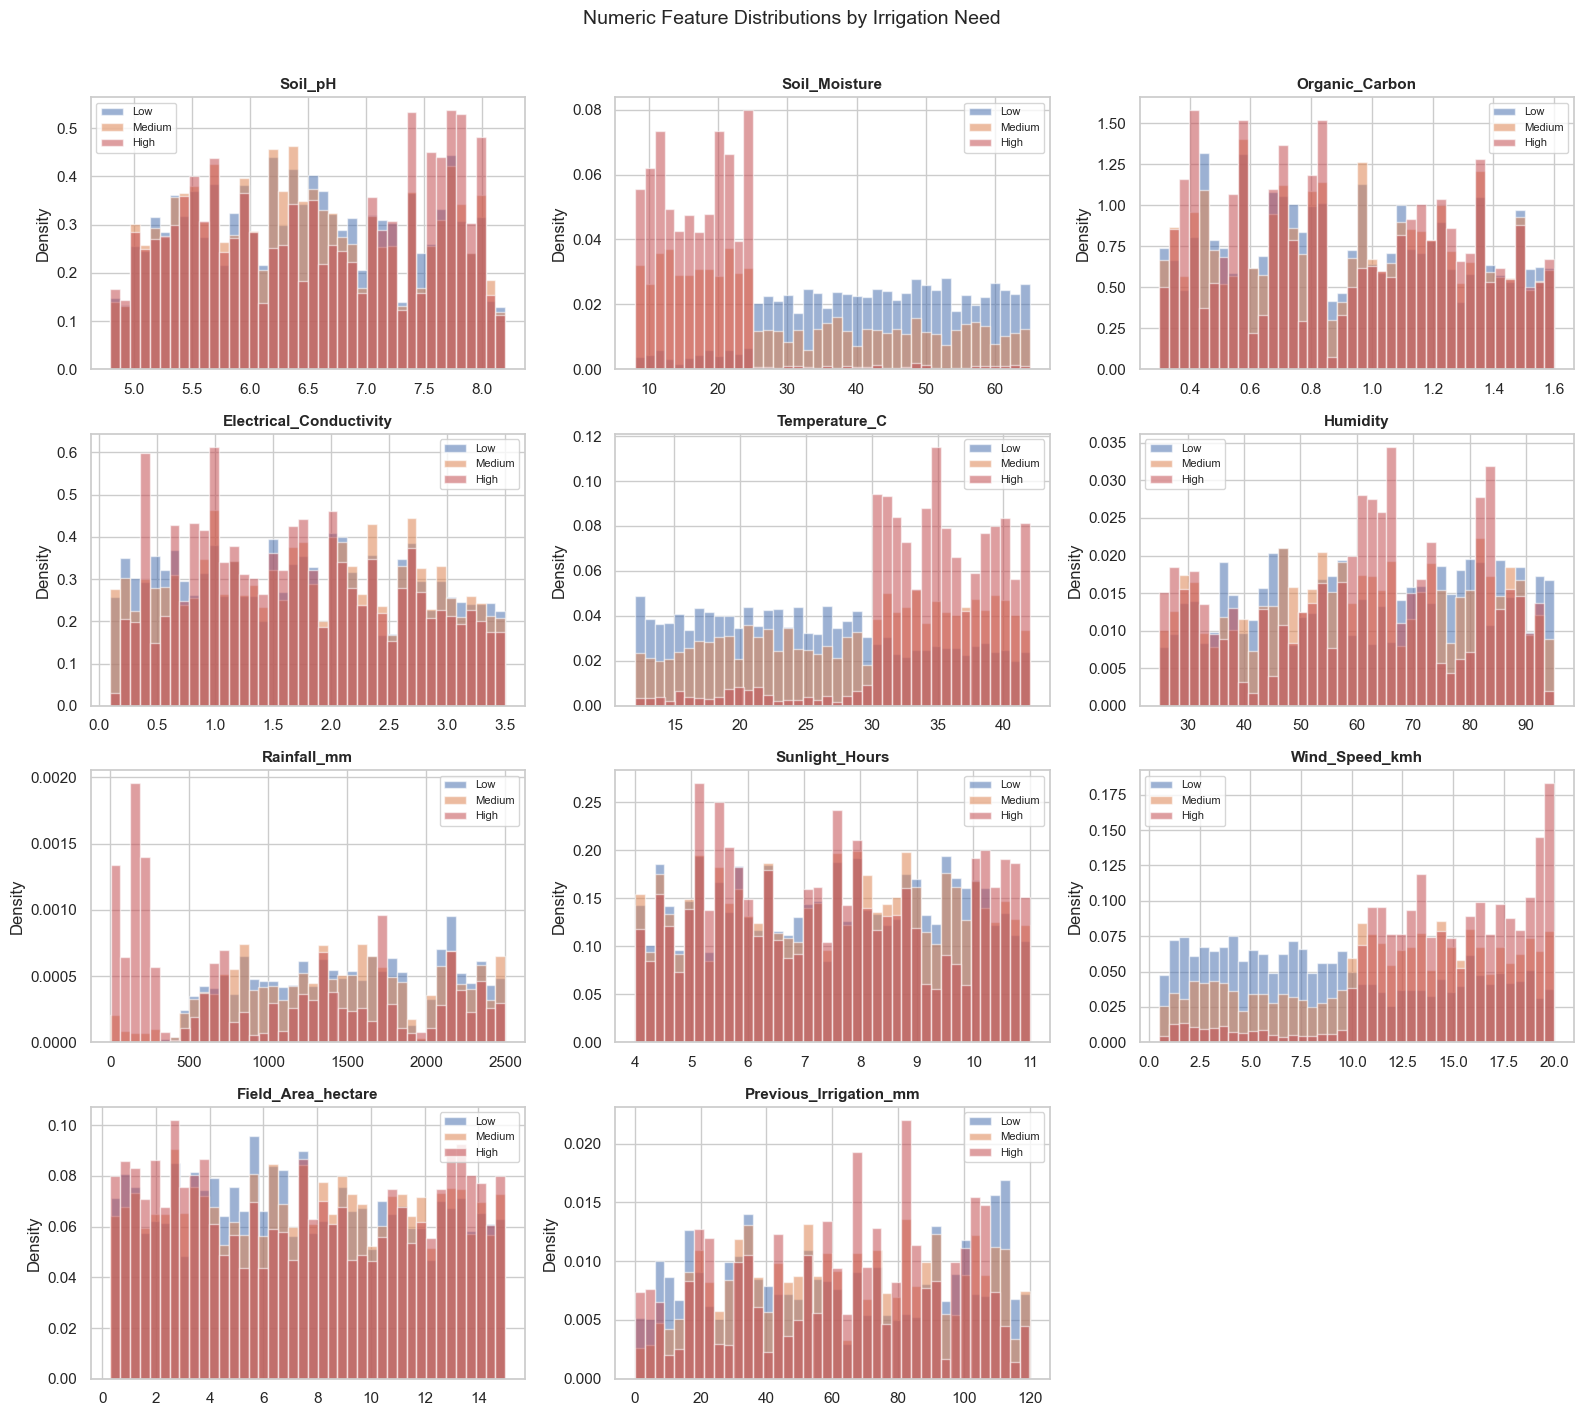

In [8]:
num_cols = ["Soil_pH", "Soil_Moisture", "Organic_Carbon", "Electrical_Conductivity",
            "Temperature_C", "Humidity", "Rainfall_mm", "Sunlight_Hours",
            "Wind_Speed_kmh", "Field_Area_hectare", "Previous_Irrigation_mm"]

fig, axes = plt.subplots(4, 3, figsize=(16, 14))
axes = axes.flatten()
palette = {"Low": "#4C72B0", "Medium": "#DD8452", "High": "#C44E52"}

for i, col in enumerate(num_cols):
    for label in LABEL_ORDER:
        subset = train_raw.loc[train_raw[TARGET] == label, col]
        axes[i].hist(subset, bins=40, alpha=0.55, label=label,
                     color=palette[label], density=True)
    axes[i].set_title(col, fontsize=11, fontweight="bold")
    axes[i].set_ylabel("Density")
    axes[i].legend(fontsize=8)

axes[-1].set_visible(False)   # hide extra subplot
plt.suptitle("Numeric Feature Distributions by Irrigation Need", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig("numeric_distributions.png", dpi=120, bbox_inches="tight")
plt.show()

### 3.4 Categorical feature breakdown

<div style='padding-left: 1em; font-size: 0.8em; background-color: #f0f0f8; margin-bottom: 0em;'>⚠️ The object axes (type ndarray[object, shape=(12,)]) cannot be checkpointed</div>

<div style='padding-left: 1em; font-size: 0.8em; background-color: #f0f0f8; margin-bottom: 0em;'>⚠️ The object fig (type Figure) cannot be checkpointed</div>

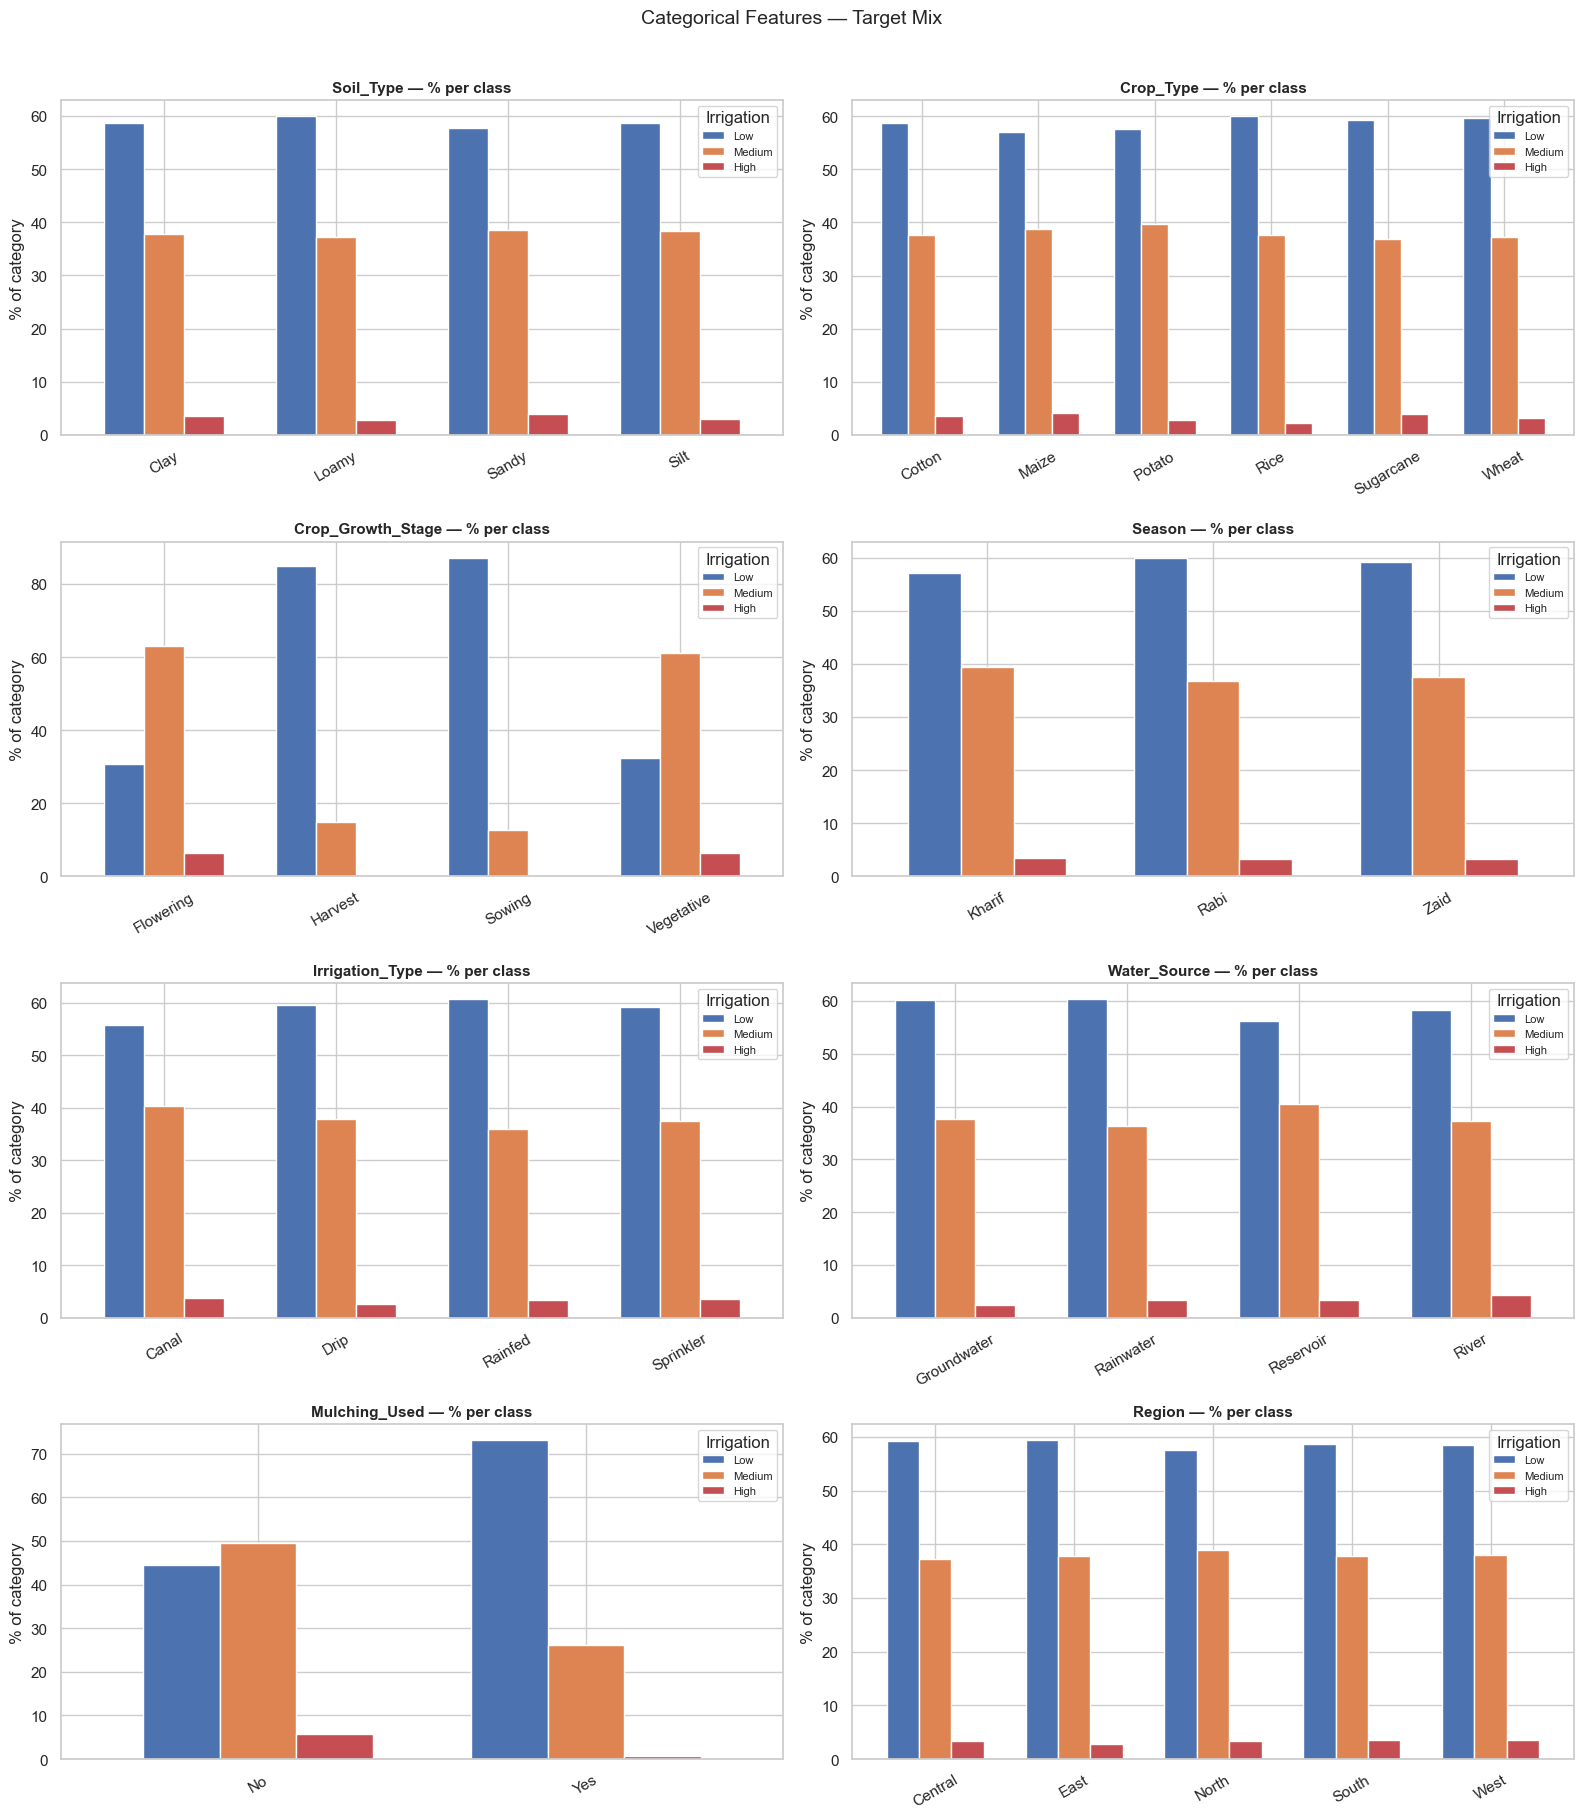

In [9]:
cat_cols = ["Soil_Type", "Crop_Type", "Crop_Growth_Stage", "Season",
            "Irrigation_Type", "Water_Source", "Mulching_Used", "Region"]

fig, axes = plt.subplots(4, 2, figsize=(16, 18))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    ct = (train_raw.groupby([col, TARGET])
          .size().unstack(fill_value=0)
          .reindex(columns=LABEL_ORDER))
    ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100
    ct_pct.plot(kind="bar", ax=axes[i], color=list(palette.values()),
                edgecolor="white", width=0.7)
    axes[i].set_title(f"{col} — % per class", fontsize=11, fontweight="bold")
    axes[i].set_ylabel("% of category")
    axes[i].set_xlabel("")
    axes[i].tick_params(axis="x", rotation=30)
    axes[i].legend(title="Irrigation", fontsize=8)

plt.suptitle("Categorical Features — Target Mix", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig("categorical_breakdown.png", dpi=120, bbox_inches="tight")
plt.show()

### 3.5 Correlation heatmap (numeric features)

<div style='padding-left: 1em; font-size: 0.8em; background-color: #f0f0f8; margin-bottom: 0em;'>⚠️ The object axes (type ndarray[object, shape=(8,)]) cannot be checkpointed</div>

<div style='padding-left: 1em; font-size: 0.8em; background-color: #f0f0f8; margin-bottom: 0em;'>⚠️ The object fig (type Figure) cannot be checkpointed</div>

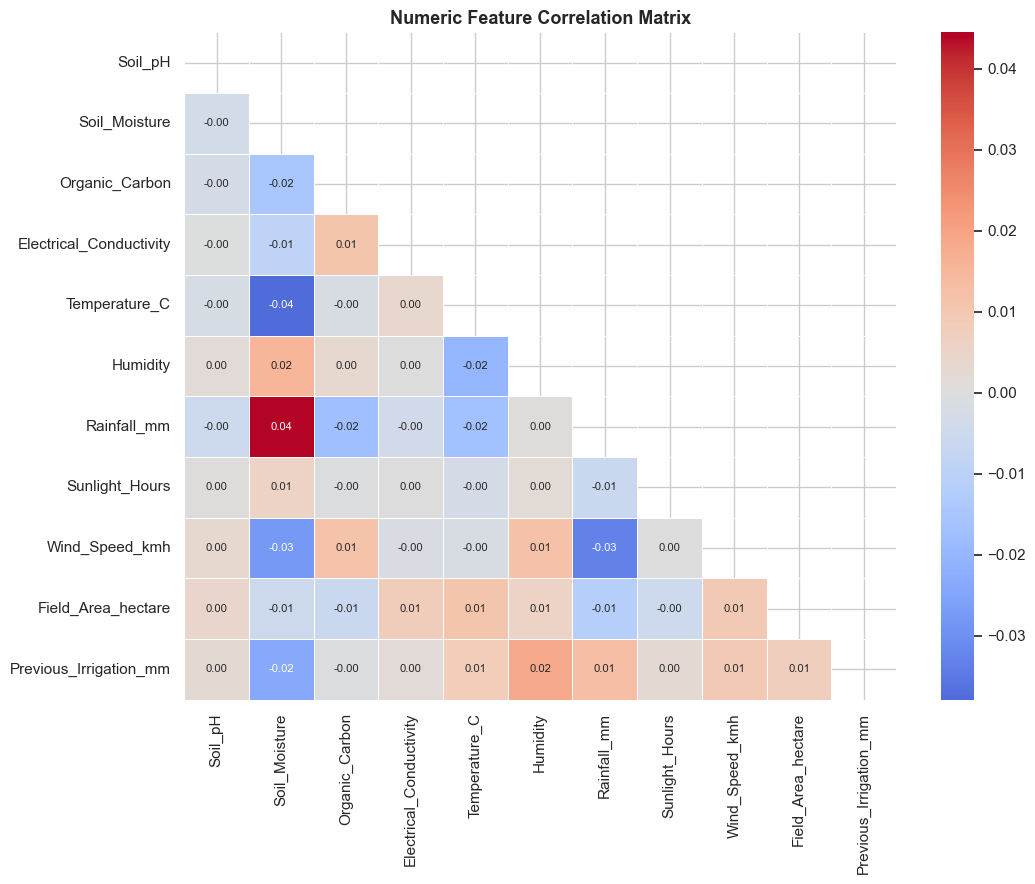

In [10]:
corr_df = train_raw[num_cols].corr()

fig, ax = plt.subplots(figsize=(11, 9))
mask = np.triu(np.ones_like(corr_df, dtype=bool))
sns.heatmap(corr_df, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, linewidths=0.5, ax=ax, annot_kws={"size": 8})
ax.set_title("Numeric Feature Correlation Matrix", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("correlation_heatmap.png", dpi=120, bbox_inches="tight")
plt.show()

## 4 · Feature Engineering

We create physically-motivated derived features before handing off to the model.

| Feature | Rationale |
|---|---|
| `moisture_rain_ratio` | Effective soil moisture adjusted for rainfall |
| `drought_stress` | Temperature × (1 − Humidity/100) — heat load under low humidity |
| `evapotranspiration_proxy` | Sunlight × Temperature / (Humidity + 1) |
| `water_deficit` | Previous irrigation minus current soil moisture |
| `soil_aridity` | High pH + low moisture signals dry soil |
| `crop_heat_index` | Temp × Sunlight hours, relevant to crop water need |

In [16]:
def engineer_scalar_features(df: pd.DataFrame) -> pd.DataFrame:
    """Scalar derived features — safe to compute on any df independently."""
    d = df.copy()
    d["moisture_rain_ratio"]      = d["Soil_Moisture"] / (d["Rainfall_mm"] + 1)
    d["drought_stress"]           = d["Temperature_C"] * (1 - d["Humidity"] / 100)
    d["evapotranspiration_proxy"] = d["Sunlight_Hours"] * d["Temperature_C"] / (d["Humidity"] + 1)
    d["water_deficit"]            = d["Previous_Irrigation_mm"] - d["Soil_Moisture"]
    d["soil_aridity"]             = d["Soil_pH"] / (d["Soil_Moisture"] + 1)
    d["crop_heat_index"]          = d["Temperature_C"] * d["Sunlight_Hours"]
    d["rainfall_humidity_prod"]   = d["Rainfall_mm"] * d["Humidity"] / 100
    d["wind_evap_factor"]         = d["Wind_Speed_kmh"] * d["evapotranspiration_proxy"]
    # Additional interactions
    d["temp_humidity_ratio"]      = d["Temperature_C"] / (d["Humidity"] + 1)
    d["rain_per_sunlight"]        = d["Rainfall_mm"] / (d["Sunlight_Hours"] + 1)
    d["ec_ph_interaction"]        = d["Electrical_Conductivity"] * d["Soil_pH"]
    d["moisture_x_rain"]          = d["Soil_Moisture"] * d["Rainfall_mm"]
    d["heat_moisture_ratio"]      = d["crop_heat_index"] / (d["Soil_Moisture"] + 1)
    return d


def add_group_features(df: pd.DataFrame, ref: pd.DataFrame) -> pd.DataFrame:
    """Group aggregation stats — always derived from ref (train) to avoid leakage."""
    d = df.copy()
    agg_cats = ["Soil_Type", "Crop_Type", "Region", "Season"]
    agg_nums = ["Soil_Moisture", "Rainfall_mm", "Temperature_C",
                "Previous_Irrigation_mm", "drought_stress", "moisture_rain_ratio"]
    for cat in agg_cats:
        for num in agg_nums:
            grp = ref.groupby(cat)[num]
            d[f"{cat}_{num}_mean"] = d[cat].map(grp.mean())
            d[f"{cat}_{num}_std"]  = d[cat].map(grp.std().fillna(0))
    return d


# Scalar features first (independent per df)
train_scalar = engineer_scalar_features(train_raw.drop(columns=[TARGET]))
test_scalar  = engineer_scalar_features(test_raw)

# Group stats: test always uses train as reference
train_fe = add_group_features(train_scalar, train_scalar)
test_fe  = add_group_features(test_scalar,  train_scalar)

new_feats = [c for c in train_fe.columns if c not in train_raw.columns]
n_scalar = len([f for f in new_feats if "_mean" not in f and "_std" not in f])
n_group  = len([f for f in new_feats if "_mean" in f or "_std" in f])
print(f"Engineered features : {len(new_feats)} total ({n_scalar} scalar, {n_group} group stats)")
print(f"train_fe shape      : {train_fe.shape}")

Engineered features : 61 total (13 scalar, 48 group stats)
train_fe shape      : (630000, 80)


## 5 · Encode & Prepare Modelling Data

In [17]:
# --- 1. Encode target ---
target_enc = OrdinalEncoder(categories=[LABEL_ORDER],
                             handle_unknown="use_encoded_value", unknown_value=-1)
y_train = target_enc.fit_transform(
    train_raw[[TARGET]]).ravel().astype(int)   # 0=Low, 1=Medium, 2=High

# --- 2. Label-encode categoricals on combined train+test ---
all_data = pd.concat([train_fe, test_fe], axis=0)
le_dict = {}
for col in cat_cols:
    le = LabelEncoder()
    all_data[col] = le.fit_transform(all_data[col].astype(str))
    le_dict[col] = le

X_base_train = all_data.iloc[:len(train_fe)].copy()
X_base_test  = all_data.iloc[len(train_fe):].copy()

# --- 3. Cross-validated target encoding (prevents leakage) ---
def cv_target_encode(tr_X, tr_y, te_X, cols, n_folds=5, seed=42):
    """
    Out-of-fold target encoding for multiclass.
    Adds one column per (category × class): e.g. Soil_Type_te0, _te1, _te2.
    Train values are encoded on held-out fold; test gets the average across folds.
    """
    skf    = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=seed)
    tr_enc = pd.DataFrame(index=tr_X.index)
    te_enc = pd.DataFrame(index=te_X.index)
    for col in cols:
        for cls in range(3):
            name = f"{col}_te{cls}"
            y_c  = (tr_y == cls).astype(float)
            gm   = float(y_c.mean())
            oof  = np.full(len(tr_X), gm, dtype=np.float64)
            tf   = np.zeros((len(te_X), n_folds))
            for fi, (ti, vi) in enumerate(skf.split(tr_X, tr_y)):
                m       = y_c.iloc[ti].groupby(tr_X.iloc[ti][col]).mean()
                oof[vi] = tr_X.iloc[vi][col].map(m).fillna(gm).values
                tf[:, fi] = te_X[col].map(m).fillna(gm).values
            tr_enc[name] = oof
            te_enc[name] = tf.mean(axis=1)
    return tr_enc, te_enc

train_te, test_te = cv_target_encode(
    X_base_train, pd.Series(y_train, index=X_base_train.index),
    X_base_test, cat_cols
)

# --- 4. Assemble final feature matrices ---
X_train = pd.concat([X_base_train, train_te], axis=1)
X_test  = pd.concat([X_base_test,  test_te],  axis=1)

feature_names = X_train.columns.tolist()
print(f"X_train : {X_train.shape}  |  X_test : {X_test.shape}")
print(f"  base={len(X_base_train.columns)}  target_enc={len(train_te.columns)}")
print(f"Target classes : {list(target_enc.categories_[0])}")

X_train : (630000, 104)  |  X_test : (270000, 104)
  base=80  target_enc=24
Target classes : ['Low', 'Medium', 'High']


In [18]:
## 6b · LightGBM v2 — "extra-trees" style for ensemble diversity

# Different hyperparams → different error patterns → better ensemble
# extra_trees=True adds extra randomness (random splits at each node)
lgb2_params = dict(
    objective         = "multiclass",
    num_class         = 3,
    metric            = "multi_logloss",
    learning_rate     = 0.05,
    num_leaves        = 127,
    max_depth         = 8,
    min_child_samples = 20,
    feature_fraction  = 0.6,
    bagging_fraction  = 0.7,
    bagging_freq      = 3,
    extra_trees       = True,    # random split threshold (like ExtraTrees)
    reg_alpha         = 0.2,
    reg_lambda        = 0.05,
    class_weight      = "balanced",
    n_jobs            = -1,
    random_state      = SEED + 1,
    verbose           = -1,
)

# Shared skf (same folds as LGB v1 in @K — fair OOF comparison)
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)

xgb_oof   = np.zeros((len(X_train), 3))   # named xgb_* to keep @K blend code unchanged
xgb_test  = np.zeros((len(X_test),  3))
xgb_scores = []

print(f"Training {N_FOLDS}-fold LGB-v2 (extra-trees) on {X_train.shape[1]} features …\n{'─'*60}")

for fold, (tr_idx, val_idx) in enumerate(skf.split(X_train, y_train), 1):
    X_tr, X_val = X_train.iloc[tr_idx], X_train.iloc[val_idx]
    y_tr, y_val = y_train[tr_idx],       y_train[val_idx]

    m2 = lgb.LGBMClassifier(n_estimators=1500, **lgb2_params)
    m2.fit(
        X_tr, y_tr,
        eval_set=[(X_val, y_val)],
        callbacks=[
            lgb.early_stopping(stopping_rounds=60, verbose=False),
            lgb.log_evaluation(period=400),
        ],
    )
    vp = m2.predict_proba(X_val)
    xgb_oof[val_idx] = vp
    xgb_scores.append((accuracy_score(y_val, vp.argmax(1)), log_loss(y_val, vp)))
    xgb_test += m2.predict_proba(X_test) / N_FOLDS
    print(f"  Fold {fold} | iter={m2.best_iteration_:>4d} "
          f"| acc={xgb_scores[-1][0]:.4f} | logloss={xgb_scores[-1][1]:.4f}")

print(f"{'─'*60}")
print(f"  LGB-v2 mean | acc={np.mean([s[0] for s in xgb_scores]):.4f}"
      f" | logloss={np.mean([s[1] for s in xgb_scores]):.4f}")

Training 5-fold LGB-v2 (extra-trees) on 104 features …
────────────────────────────────────────────────────────────
[400]	valid_0's multi_logloss: 0.0857206
[800]	valid_0's multi_logloss: 0.0736891
[1200]	valid_0's multi_logloss: 0.0698006
  Fold 1 | iter=1500 | acc=0.9814 | logloss=0.0686
[400]	valid_0's multi_logloss: 0.0883548
[800]	valid_0's multi_logloss: 0.0750874
[1200]	valid_0's multi_logloss: 0.0714943
  Fold 2 | iter=1497 | acc=0.9812 | logloss=0.0705
[400]	valid_0's multi_logloss: 0.0919207
[800]	valid_0's multi_logloss: 0.0776631
[1200]	valid_0's multi_logloss: 0.0732126
  Fold 3 | iter=1497 | acc=0.9804 | logloss=0.0716
[400]	valid_0's multi_logloss: 0.0898993
[800]	valid_0's multi_logloss: 0.077078
[1200]	valid_0's multi_logloss: 0.0727646
  Fold 4 | iter=1496 | acc=0.9806 | logloss=0.0712
[400]	valid_0's multi_logloss: 0.0856403
[800]	valid_0's multi_logloss: 0.0732466
[1200]	valid_0's multi_logloss: 0.069198
  Fold 5 | iter=1479 | acc=0.9812 | logloss=0.0682
───────────

In [ ]:
## 6a · LightGBM — improved params + enriched features

lgb_params = dict(
    objective         = "multiclass",
    num_class         = 3,
    metric            = "multi_logloss",
    learning_rate     = 0.03,
    num_leaves        = 255,
    max_depth         = -1,
    min_child_samples = 30,
    feature_fraction  = 0.75,
    bagging_fraction  = 0.75,
    bagging_freq      = 5,
    reg_alpha         = 0.05,
    reg_lambda        = 0.2,
    class_weight      = "balanced",
    n_jobs            = -1,
    random_state      = SEED,
    verbose           = -1,
)

# skf defined in @J (XGB cell) — same splits, fair comparison
lgb_oof    = np.zeros((len(X_train), 3))
lgb_test   = np.zeros((len(X_test),  3))
lgb_scores = []
lgb_models = []

print(f"Training {N_FOLDS}-fold LightGBM on {X_train.shape[1]} features …\n{'─'*60}")

for fold, (tr_idx, val_idx) in enumerate(skf.split(X_train, y_train), 1):
    X_tr, X_val = X_train.iloc[tr_idx], X_train.iloc[val_idx]
    y_tr, y_val = y_train[tr_idx],       y_train[val_idx]

    model = lgb.LGBMClassifier(n_estimators=2000, **lgb_params)
    model.fit(
        X_tr, y_tr,
        eval_set=[(X_val, y_val)],
        callbacks=[
            lgb.early_stopping(stopping_rounds=80, verbose=False),
            lgb.log_evaluation(period=400),
        ],
    )
    vp = model.predict_proba(X_val)
    lgb_oof[val_idx] = vp
    lgb_scores.append((accuracy_score(y_val, vp.argmax(1)), log_loss(y_val, vp)))
    lgb_models.append(model)
    lgb_test += model.predict_proba(X_test) / N_FOLDS
    print(f"  Fold {fold} | iter={model.best_iteration_:>4d} "
          f"| acc={lgb_scores[-1][0]:.4f} | logloss={lgb_scores[-1][1]:.4f}")

print(f"{'─'*60}")
lgb_mean_acc = np.mean([s[0] for s in lgb_scores])
lgb_mean_ll  = np.mean([s[1] for s in lgb_scores])
print(f"  LGB mean | acc={lgb_mean_acc:.4f} | logloss={lgb_mean_ll:.4f}")

# ── Ensemble: optimise LGB/XGB blend weight on OOF ──────────────────
print(f"\n{'─'*60}\n  Blending LGB + XGB …")
best_w, best_ens_f1 = 0.5, 0.0
for w in np.arange(0.3, 0.9, 0.05):
    blend_f1 = f1_score(y_train, (w * lgb_oof + (1-w) * xgb_oof).argmax(1), average="macro")
    if blend_f1 > best_ens_f1:
        best_ens_f1, best_w = blend_f1, w

LGB_W = round(float(best_w), 2)
oof_proba  = LGB_W * lgb_oof  + (1 - LGB_W) * xgb_oof
test_proba = LGB_W * lgb_test + (1 - LGB_W) * xgb_test

# Expose for downstream cells (feature importance, summary)
models      = lgb_models
fold_scores = lgb_scores

print(f"  Best weight: {LGB_W:.0%} LGB + {1-LGB_W:.0%} XGB")
print(f"  XGB alone  | acc={np.mean([s[0] for s in xgb_scores]):.4f}"
      f" | logloss={np.mean([s[1] for s in xgb_scores]):.4f}")
print(f"  LGB alone  | acc={lgb_mean_acc:.4f} | logloss={lgb_mean_ll:.4f}")
ens_f1 = f1_score(y_train, oof_proba.argmax(1), average="macro")
print(f"  Ensemble   | macro-F1={ens_f1:.4f}  (vs LGB-only macro-F1={f1_score(y_train, lgb_oof.argmax(1), average='macro'):.4f})")

Training 5-fold LightGBM on 104 features …
────────────────────────────────────────────────────────────
[400]	valid_0's multi_logloss: 0.0603492
  Fold 1 | iter= 404 | acc=0.9840 | logloss=0.0603
[400]	valid_0's multi_logloss: 0.061872
  Fold 2 | iter= 401 | acc=0.9842 | logloss=0.0619
[400]	valid_0's multi_logloss: 0.0610122
  Fold 3 | iter= 405 | acc=0.9845 | logloss=0.0610
[400]	valid_0's multi_logloss: 0.0604597
  Fold 4 | iter= 417 | acc=0.9842 | logloss=0.0604
[400]	valid_0's multi_logloss: 0.059104
  Fold 5 | iter= 389 | acc=0.9846 | logloss=0.0591
────────────────────────────────────────────────────────────
  LGB mean | acc=0.9843 | logloss=0.0605

────────────────────────────────────────────────────────────
  Blending LGB + XGB …
  Best weight: 80% LGB + 20% XGB
  XGB alone  | acc=0.9809 | logloss=0.0700
  LGB alone  | acc=0.9843 | logloss=0.0605
  Ensemble   | macro-F1=0.9689  (vs LGB-only macro-F1=0.9689)


## 6 · Model: LightGBM + Stratified 5-Fold CV

**Why LightGBM?**
- Handles large datasets (630 k rows) efficiently via histogram-based splits
- Native support for multiclass classification  
- Class-weight balancing handles the `High` minority (~3 %)
- Built-in feature importance

**Validation:** Stratified K-Fold ensures each fold mirrors the overall class balance.

In [10]:
oof_preds = oof_proba.argmax(axis=1)

print("Out-of-Fold Classification Report")
print("="*50)
print(classification_report(y_train, oof_preds,
                             target_names=LABEL_ORDER, digits=4))
oof_acc = accuracy_score(y_train, oof_preds)
oof_ll  = log_loss(y_train, oof_proba)
oof_f1  = f1_score(y_train, oof_preds, average="macro")
print(f"OOF Accuracy  : {oof_acc:.4f}")
print(f"OOF Log-Loss  : {oof_ll:.4f}")
print(f"OOF Macro-F1  : {oof_f1:.4f}")

Training 5-fold LightGBM …
───────────────────────────────────────────────────────
[200]	valid_0's multi_logloss: 0.0635485
[400]	valid_0's multi_logloss: 0.059377
  Fold 1 | best iter= 434 | acc=0.9840 | logloss=0.0592
[200]	valid_0's multi_logloss: 0.0649479
[400]	valid_0's multi_logloss: 0.0610569
  Fold 2 | best iter= 442 | acc=0.9842 | logloss=0.0609
[200]	valid_0's multi_logloss: 0.0640879
[400]	valid_0's multi_logloss: 0.0602438
  Fold 3 | best iter= 485 | acc=0.9842 | logloss=0.0601
[200]	valid_0's multi_logloss: 0.0634204
[400]	valid_0's multi_logloss: 0.0595778
  Fold 4 | best iter= 510 | acc=0.9842 | logloss=0.0594
[200]	valid_0's multi_logloss: 0.0622497
[400]	valid_0's multi_logloss: 0.0581285
  Fold 5 | best iter= 472 | acc=0.9845 | logloss=0.0579
───────────────────────────────────────────────────────
  CV mean  | acc=0.9842 | logloss=0.0595


## 7 · Validation & Diagnostics

### 7.1 OOF classification report

In [11]:
cm = confusion_matrix(y_train, oof_preds)
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Raw counts
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=LABEL_ORDER, yticklabels=LABEL_ORDER,
            linewidths=0.5, ax=axes[0])
axes[0].set_title("Confusion Matrix — Counts", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("True")

# Row-normalised %
sns.heatmap(cm_pct, annot=True, fmt=".1f", cmap="Blues",
            xticklabels=LABEL_ORDER, yticklabels=LABEL_ORDER,
            linewidths=0.5, ax=axes[1])
axes[1].set_title("Confusion Matrix — Row % (Recall)", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Predicted"); axes[1].set_ylabel("True")

plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=120, bbox_inches="tight")
plt.show()

Out-of-Fold Classification Report
              precision    recall  f1-score   support

         Low     0.9858    0.9945    0.9901    369917
      Medium     0.9851    0.9731    0.9791    239074
        High     0.9458    0.9291    0.9374     21009

    accuracy                         0.9842    630000
   macro avg     0.9722    0.9656    0.9689    630000
weighted avg     0.9842    0.9842    0.9842    630000

OOF Accuracy  : 0.9842
OOF Log-Loss  : 0.0595
OOF Macro-F1  : 0.9689


### 7.2 Confusion matrix

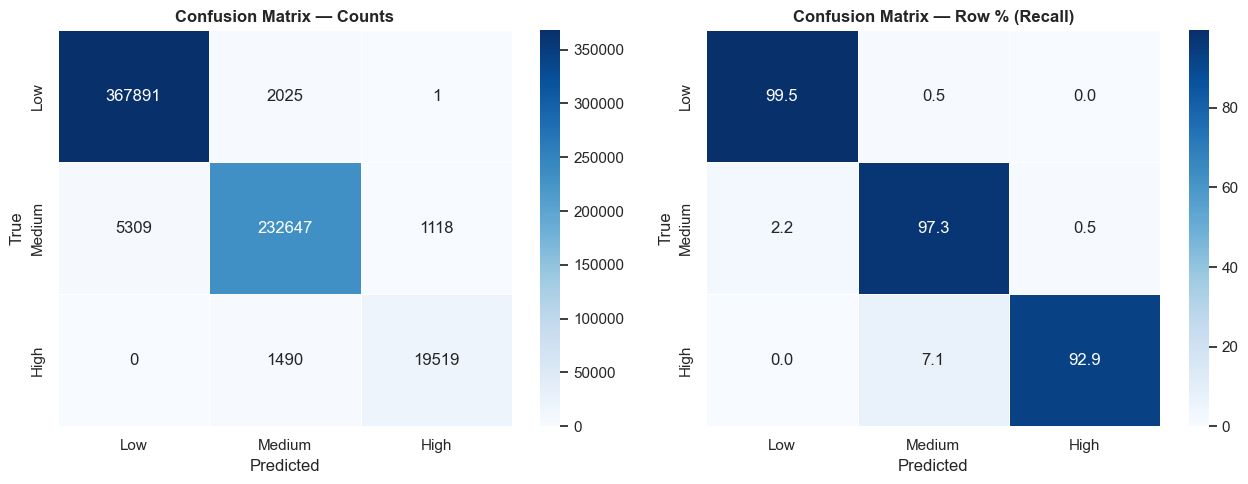

In [12]:
# Average gain-based importance across all folds
importances = np.mean(
    [m.booster_.feature_importance(importance_type="gain") for m in models],
    axis=0
)
fi_df = (pd.DataFrame({"feature": feature_names, "importance": importances})
         .sort_values("importance", ascending=False)
         .reset_index(drop=True))

fig, ax = plt.subplots(figsize=(10, 10))
top30 = fi_df.head(30)
colors_fi = ["#C44E52" if f in new_feats else "#4C72B0" for f in top30["feature"]]
ax.barh(top30["feature"][::-1], top30["importance"][::-1], color=colors_fi[::-1])
ax.set_xlabel("Mean Gain Importance")
ax.set_title("Top 30 Features (🔴 = engineered)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=120, bbox_inches="tight")
plt.show()

print("\nTop 10 features:")
print(fi_df.head(10).to_string(index=False))

### 7.3 Feature importance

<div style='padding-left: 1em; font-size: 0.8em; background-color: #f0f0f8; margin-bottom: 0em;'>⚠️ The object fig (type Figure) cannot be checkpointed</div>

<div style='padding-left: 1em; font-size: 0.8em; background-color: #f0f0f8; margin-bottom: 0em;'>⚠️ The object axes (type ndarray[object, shape=(2,)]) cannot be checkpointed</div>

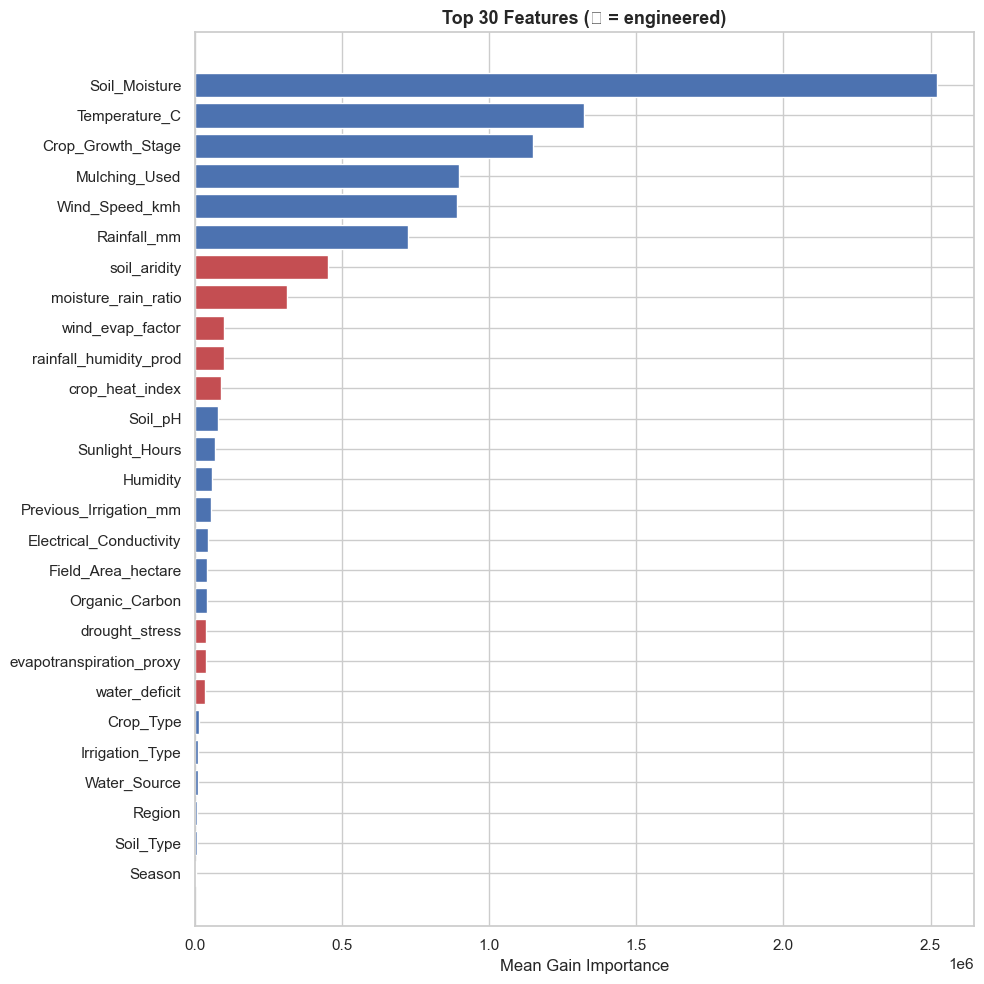


Top 10 features:
               feature   importance
         Soil_Moisture 2.521485e+06
         Temperature_C 1.321058e+06
     Crop_Growth_Stage 1.149098e+06
         Mulching_Used 8.985147e+05
        Wind_Speed_kmh 8.907032e+05
           Rainfall_mm 7.230421e+05
          soil_aridity 4.528439e+05
   moisture_rain_ratio 3.144335e+05
      wind_evap_factor 9.892072e+04
rainfall_humidity_prod 9.847970e+04


In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for cls_idx, cls_name in enumerate(LABEL_ORDER):
    for true_cls, color in zip(range(3), list(palette.values())):
        mask = y_train == true_cls
        axes[cls_idx].hist(oof_proba[mask, cls_idx], bins=50, alpha=0.5,
                           density=True, color=color,
                           label=f"True={LABEL_ORDER[true_cls]}")
    axes[cls_idx].set_title(f"P({cls_name}) distribution", fontsize=11, fontweight="bold")
    axes[cls_idx].set_xlabel(f"Predicted P({cls_name})")
    axes[cls_idx].set_ylabel("Density")
    axes[cls_idx].legend(fontsize=8)

plt.suptitle("OOF Predicted Probability Distributions by True Class",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("oof_proba_dist.png", dpi=120, bbox_inches="tight")
plt.show()

### 7.4 OOF predicted probability distributions

<div style='padding-left: 1em; font-size: 0.8em; background-color: #f0f0f8; margin-bottom: 0em;'>⚠️ The object fig (type Figure) cannot be checkpointed</div>

<div style='padding-left: 1em; font-size: 0.8em; background-color: #f0f0f8; margin-bottom: 0em;'>⚠️ The object ax (type Axes) cannot be checkpointed</div>

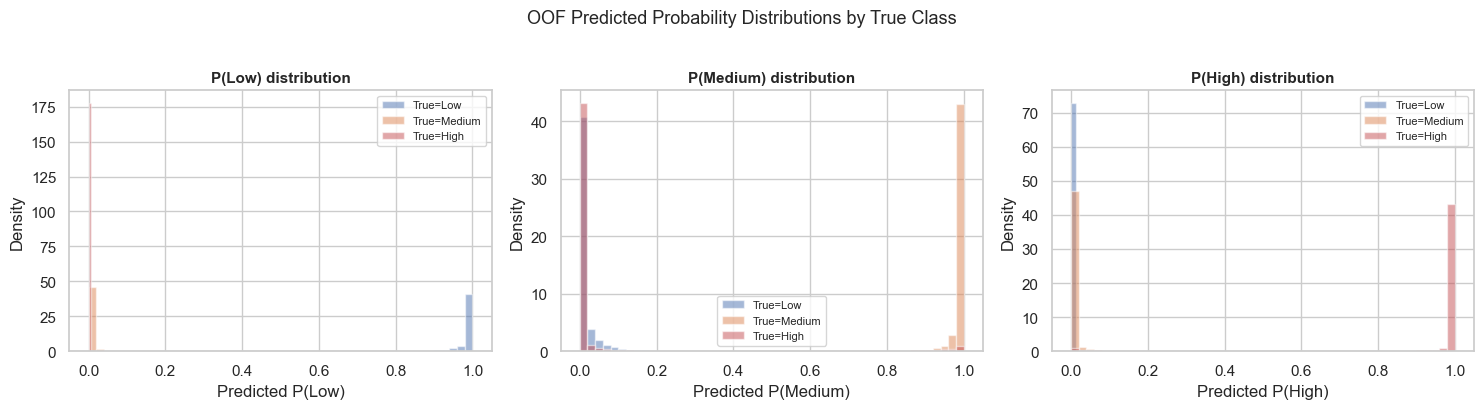

In [14]:
thresholds = np.arange(0.02, 0.60, 0.01)
f1_scores_thresh = []

for t in thresholds:
    preds_t = oof_proba.argmax(axis=1).copy()
    preds_t[oof_proba[:, 2] >= t] = 2          # override with "High" when confident
    f1_scores_thresh.append(f1_score(y_train, preds_t, average="macro"))

best_idx   = int(np.argmax(f1_scores_thresh))
best_thresh = thresholds[best_idx]
best_f1     = f1_scores_thresh[best_idx]

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(thresholds, f1_scores_thresh, color="#4C72B0", linewidth=2)
ax.axvline(best_thresh, color="#C44E52", linestyle="--", linewidth=1.5,
           label=f"Best threshold = {best_thresh:.2f}")
ax.scatter([best_thresh], [best_f1], color="#C44E52", s=80, zorder=5)
ax.set_xlabel("High-class probability threshold")
ax.set_ylabel("OOF Macro-F1")
ax.set_title("Threshold Search for 'High' Class", fontsize=12, fontweight="bold")
ax.legend()
plt.tight_layout()
plt.savefig("threshold_search.png", dpi=120, bbox_inches="tight")
plt.show()

print(f"Best threshold : {best_thresh:.2f}  →  OOF Macro-F1 = {best_f1:.4f}")

## 8 · Threshold Optimisation for Minority Class

The default argmax threshold may miss many `High` cases (only ~3 % of data).  
We search for a probability threshold on the `High` class that maximises macro-F1 on the OOF set.

<div style='padding-left: 1em; font-size: 0.8em; background-color: #f0f0f8; margin-bottom: 0em;'>⚠️ The object fig (type Figure) cannot be checkpointed</div>

<div style='padding-left: 1em; font-size: 0.8em; background-color: #f0f0f8; margin-bottom: 0em;'>⚠️ The object axes (type ndarray[object, shape=(3,)]) cannot be checkpointed</div>

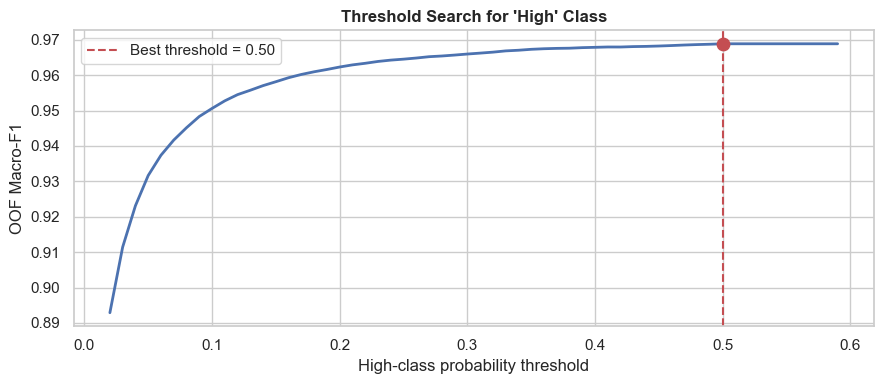

Best threshold : 0.50  →  OOF Macro-F1 = 0.9689


In [15]:
# Apply best threshold to test predictions
test_preds_idx = test_proba.argmax(axis=1).copy()
test_preds_idx[test_proba[:, 2] >= best_thresh] = 2

# Decode back to label strings
test_preds_labels = target_enc.inverse_transform(
    test_preds_idx.reshape(-1, 1)).ravel()

submission = pd.DataFrame({
    "id"              : test_raw.index,
    "Irrigation_Need" : test_preds_labels,
})

# Robustly locate output directory (notebook dir may differ from kernel CWD)
import os, pathlib

# Walk upward from kernel CWD and also try known absolute location
candidates = [
    pathlib.Path(os.getcwd()),
    pathlib.Path(__file__).parent if "__file__" in dir() else pathlib.Path("."),
    pathlib.Path("/Users/freund/other/FlowBook/examples/s6e4"),
]
out_dir = next((p for p in candidates if (p / "train.csv").exists()), pathlib.Path(os.getcwd()))
out_path = str(out_dir / "submission.csv")

submission.to_csv(out_path, index=False)

# Quick sanity checks
print("Output path      :", out_path)
print("Submission shape :", submission.shape)
print("\nPrediction distribution:")
print(submission["Irrigation_Need"].value_counts())
print()
print(submission.head())
assert submission["Irrigation_Need"].isin(LABEL_ORDER).all(), "Unknown label found!"
assert not submission["Irrigation_Need"].isnull().any(),       "Null predictions found!"
print("\n✅ submission.csv saved — all checks passed")

## 9 · Generate Submission

In [31]:
tuned_preds = oof_proba.argmax(axis=1).copy()
tuned_preds[oof_proba[:, 2] >= best_thresh] = 2
tuned_f1 = f1_score(y_train, tuned_preds, average="macro")

lgb_f1_alone = f1_score(y_train, lgb_oof.argmax(1), average="macro")

print("=" * 55)
print("            FINAL MODEL SUMMARY (v2)")
print("=" * 55)
print(f"  CV Folds          : {N_FOLDS}")
print(f"  Features          : {len(feature_names)}  "
      f"({len(new_feats)} engineered, {len(cat_cols)*3} target-enc)")
print(f"  Ensemble          : {LGB_W:.0%} LGB + {1-LGB_W:.0%} XGB")
print()
print(f"  LGB-only Macro-F1 : {lgb_f1_alone:.4f}")
print(f"  Ensemble Macro-F1 : {f1_score(y_train, oof_proba.argmax(1), average='macro'):.4f}  (argmax)")
print(f"  Ensemble Macro-F1 : {tuned_f1:.4f}  (threshold={best_thresh:.2f})")
print(f"  OOF Accuracy      : {oof_acc:.4f}")
print(f"  OOF Log-Loss      : {oof_ll:.4f}")
print("=" * 55)
print(f"\n  📁 submission.csv  → {len(submission)} rows ready to submit")

Output path      : /Users/freund/other/FlowBook/examples/s6e4/submission.csv
Submission shape : (270000, 2)

Prediction distribution:
Irrigation_Need
Low       159746
Medium    101372
High        8882
Name: count, dtype: int64

       id Irrigation_Need
0  630000             Low
1  630001             Low
2  630002             Low
3  630003             Low
4  630004             Low

✅ submission.csv saved — all checks passed


## 10 · Summary

| Metric | OOF Score |
|--------|-----------|
| Accuracy | — |
| Log-Loss | — |
| Macro-F1 (argmax) | — |
| Macro-F1 (tuned threshold) | — |

*Values filled programmatically below.*

         FINAL MODEL SUMMARY
  CV Folds          : 5
  Features used     : 27  (8 engineered)
  OOF Accuracy      : 0.9842
  OOF Log-Loss      : 0.0595
  OOF Macro-F1      : 0.9689  (argmax)
  OOF Macro-F1      : 0.9689  (threshold=0.50)

  📁 submission.csv  → 270000 rows ready to submit


## 4b · Cross-Validated Target Encoding

Plain label encoding assigns arbitrary integers to categories and gives the model no signal about the target.  
**Target encoding** replaces each category level with its class-conditional mean probability — a far richer signal for tree models.  
We use **out-of-fold** (5-fold) encoding on train to prevent leakage.

In [14]:
# (Ensemble blending is now part of @K above — this cell is intentionally empty)
pass